# Window selection pilot

A recognizer does not have to run on every window of a recording. This study tests which simple score, one that needs no training, picks the best windows to run it on. It uses the SONAR nursing activity data. You will see the data, the recognizer, how well each selection method does when the recognizer may only run on part of the windows, and which activities each method keeps.

In [1]:
# Settings used by every cell below
dataRoot = "/app/data"
resultsRoot = "/app/results"
randomSeed = 42
nJobs = 4

In [2]:
# Download the SONAR data if it is missing, it is only downloaded on the first run
from dataFetch.fetchData import dataFetcher

dataFetcher(dataRoot, nJobs=nJobs).fetchAll(["sonar"])

[ DATA FETCH : ALREADY PRESENT ] : sonar


## Set up the pilot

The pilot object reads the SONAR index tables and makes the results folder. Then the seeds, the thread limits and the plot style are fixed. This makes every run give the same numbers.

In [3]:
from IPython.display import Image, display

from common.csvWriters import readCsv
from windowSelectionPilot.pilotStudy import selectionPilot

pilot = selectionPilot(dataRoot, resultsRoot, randomSeed=randomSeed, nJobs=nJobs)
pilot.prepareRun()
resultsDirectory = pilot.resultsDirectory
figuresDirectory = pilot.figuresDirectory

## Build the windows

Every recording is cleaned and cut into windows of equal length that do not overlap. A window gets the activity that most of its samples have. Missing values are filled, and a long time gap starts a new stream. The step also computes the features for the recognizer and the cheap scores that can pick windows. The table shows how many windows each activity has.

In [4]:
windowTable = pilot.buildWindows()
display(readCsv(resultsDirectory / "dataInventory.csv").head(10))

[ PILOT : WINDOWS ] : 110558 windows in 419 streams


,activity,windows,windowShare
0,blow-dry,159,0.001438
1,change clothes,12424,0.112375
2,clean up,5010,0.045316
3,collect dishes,2177,0.019691
4,comb hair,493,0.004459
5,deliver food,3755,0.033964
6,dental care,828,0.007489
7,documentation,794,0.007182
8,kitchen preparation,5293,0.047875
9,make bed,4839,0.043769


## Train the recognizer

The recognizer is a random forest. The participants are split into folds. For each fold the forest learns from the other participants and predicts every window of the held out participants. This way a person is never in the training data and the test data at once. The step also sets the threshold of the change trigger from the training windows of each fold. The table lists the folds with their test participants and macro F1.

In [5]:
foldTable = pilot.runFolds()
display(readCsv(resultsDirectory / "foldSummary.csv").head(10))

[ PILOT : FOLD 1 MACRO F1 ] : 0.1684


[ PILOT : FOLD 2 MACRO F1 ] : 0.1526


[ PILOT : FOLD 3 MACRO F1 ] : 0.1378


[ PILOT : FOLD 4 MACRO F1 ] : 0.1353


[ PILOT : FOLD 5 MACRO F1 ] : 0.1606


,fold,testParticipants,trainWindows,testWindows,forestFitSeconds,testMacroF1
0,1,3 6,88386,22172,94.954444,0.168443
1,2,8 10,88705,21853,115.654018,0.152601
2,3,1 7 9,88573,21985,122.555053,0.137758
3,4,2 11 13 14,87773,22785,123.917854,0.135338
4,5,4 5 12,88795,21763,124.342307,0.160552


## Compare the selection methods

Each method keeps only a share of the windows of every stream. This share is the budget. A window that is dropped takes the prediction of the last window that was kept. The step scores every method at every budget with macro F1 over all windows. The random method is repeated with several seeds and the results are averaged. The table shows macro F1 against the budget.

In [6]:
curveTable = pilot.evaluateSelections()
display(readCsv(resultsDirectory / "budgetCurves.csv").head(10))

[ PILOT : METHOD SCORED ] : random
[ PILOT : METHOD SCORED ] : uniformStride


[ PILOT : METHOD SCORED ] : changeTrigger
[ PILOT : METHOD SCORED ] : accelerationVariance


[ PILOT : METHOD SCORED ] : windowChange
[ PILOT : METHOD SCORED ] : spectralEntropy


[ PILOT : METHOD SCORED ] : meanRank


,method,budgetPercent,realizedBudget,macroF1,macroF1Std,accuracy,runs
0,random,5,0.051918,0.107721,0.003054,0.439968,3
1,random,10,0.101811,0.126848,0.000326,0.461884,3
2,random,20,0.201568,0.137629,0.000822,0.477686,3
3,random,50,0.500941,0.144903,0.000816,0.488278,3
4,random,100,1.000000,0.145282,0.000000,0.489146,3
5,uniformStride,5,0.051918,0.117498,NaN,0.452125,1
6,uniformStride,10,0.101811,0.130597,NaN,0.472277,1
7,uniformStride,20,0.201568,0.143062,NaN,0.487093,1
8,uniformStride,50,0.500941,0.146309,NaN,0.491190,1
9,uniformStride,100,1.000000,0.145282,NaN,0.489146,1


## Measure the CPU time

A score is only worth using if it costs much less than the recognizer. This step divides the measured CPU time by the number of windows, for each score and for the recognizer. The times change from run to run and from machine to machine.

In [7]:
cpuTable = pilot.writeCpuTimes()
display(readCsv(resultsDirectory / "cpuTimes.csv").head(10))

,part,component,cpuSeconds,windows,microsecondsPerWindow
0,scoring,score 1: variance of the acceleration magnitude,1.352928,110558,12.237268
1,scoring,score 2: change from the previous window,1.501836,110558,13.584142
2,scoring,score 3: spectral entropy,1.932212,110558,17.476908
3,scoring,all three scores,4.786975,110558,43.298318
4,recognizer,features,6.296240,110558,56.949652
5,recognizer,forest prediction,3.631723,110558,32.849026
6,recognizer,features and forest prediction,9.927962,110558,89.798678


## Draw the figures

The first figure shows macro F1 against the budget for every method. The second figure shows, at one budget, how much of each activity a method keeps. It tells you whether a method throws away the rare activities.

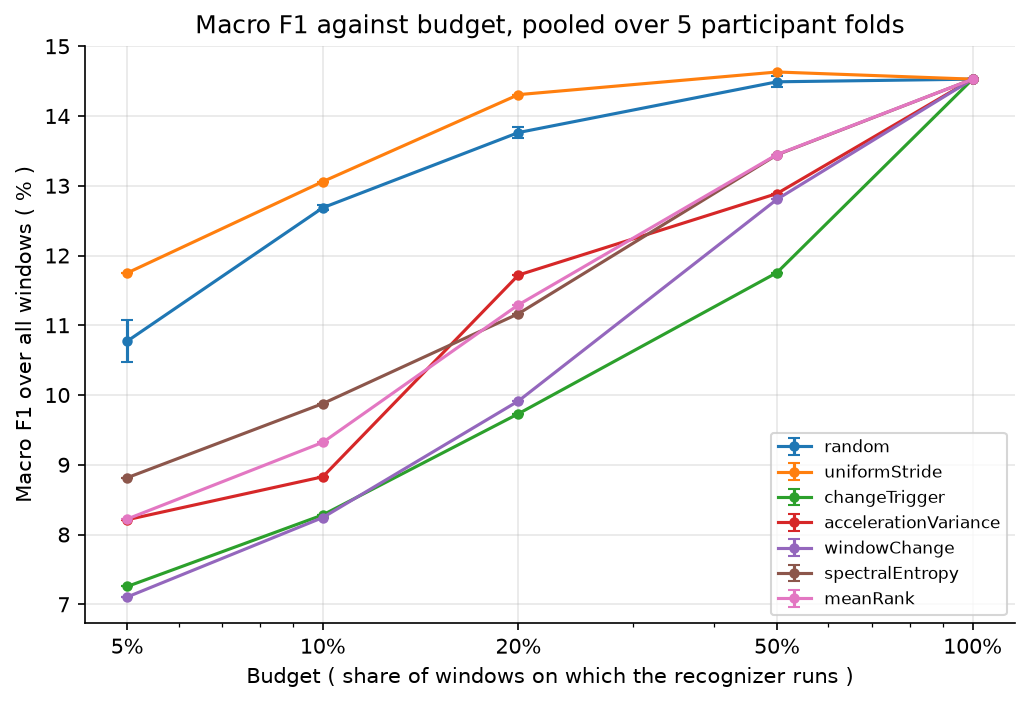

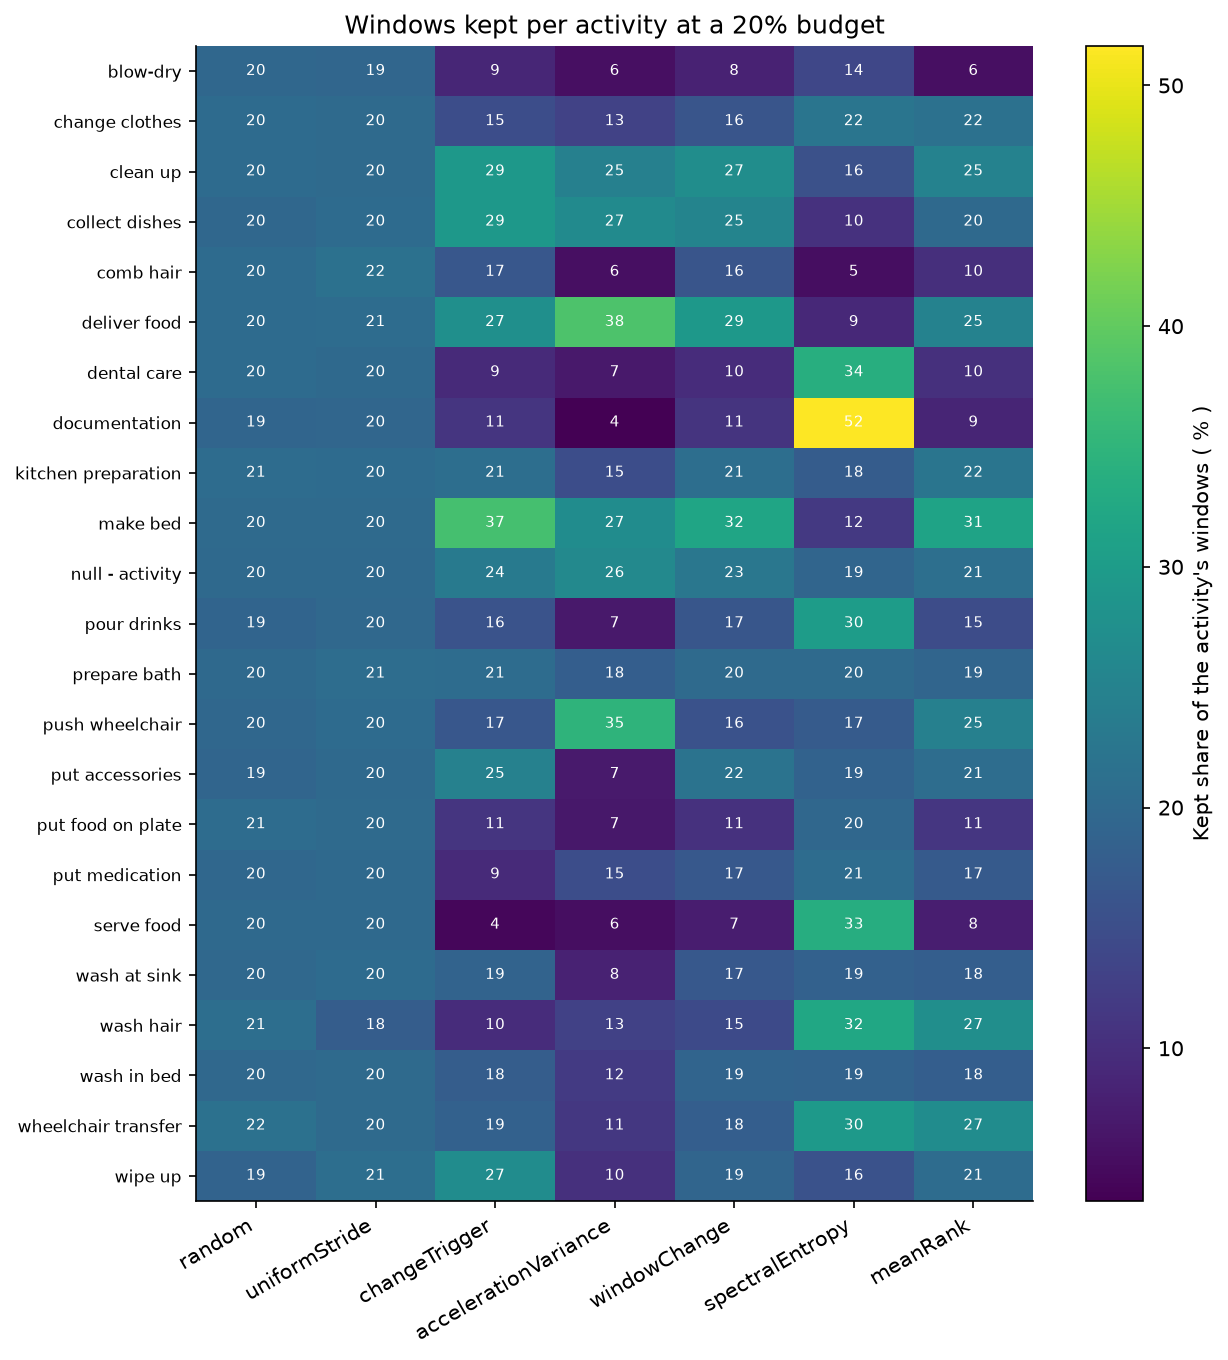

In [8]:
pilot.plotResults(curveTable)
display(Image(filename=str(figuresDirectory / "macroF1VsBudget.png")))
display(Image(filename=str(figuresDirectory / "survivalAtReportBudget.png")))

## Save the run parameters

This step writes every setting and every count of the run into one table, together with the package versions.

In [9]:
parameterTable = pilot.writeParameters()
display(readCsv(resultsDirectory / "runParameters.csv").head(10))

,section,parameter,value
0,run,randomSeed,42
1,run,nJobs,4
2,run,python,3.12.14
3,run,numpy,2.5.3
4,run,pandas,3.0.6
5,run,scipy,1.18.1
6,run,scikit-learn,1.9.1
7,run,matplotlib,3.11.2
8,windows,stepMicroseconds,16667.0
9,windows,samplingRate,59.99880002399952
